# Deep Q Network for Atari MsPacman

This project trains a DQN agent to play Atari MsPacman using:
- CNN-based Q-network
- Experience Replay
- Target Network
- Frame Stacking
- Epsilon-greedy exploration

## 1. Setup and Dependencies

This section imports all required libraries for environment interaction, preprocessing, and model training.

In [1]:
!pip install -q gymnasium[atari,accept-rom-license]
!pip install -q ale-py
!pip install -q autorom
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [2]:
import gymnasium as gym
import ale_py
import numpy as np
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

## 2. Environment Initialization

The Atari MsPacman environment is created using Gymnasium with RGB observations.

In [3]:
env = gym.make(
    "ALE/MsPacman-v5",
    obs_type="rgb",
    frameskip=2,
    repeat_action_probability=0.0
)

print("Observation:", env.observation_space.shape)
print("Actions:", env.action_space.n)


Observation: (210, 160, 3)
Actions: 9


In [4]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

## 3. Frame Preprocessing and Stacking

Raw frames are converted to grayscale, resized, and stacked to provide temporal information to the agent.

In [5]:
class FrameStacker:
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)

    def preprocess(self, frame):
        frame = np.array(frame)

        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        frame = cv2.resize(frame, (84, 84))
        frame = frame.astype(np.float16) / 255.0
        return frame  # (84, 84)

    def reset(self, obs):
        frame = self.preprocess(obs)
        self.frames.clear()
        for _ in range(self.k):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)  # (4, 84, 84)

    def step(self, obs):
        frame = self.preprocess(obs)
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)


## 4. DQN Model Architecture

A convolutional neural network is used to estimate Q-values from stacked frames.

In [6]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(7 * 7 * 64, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)  # SAFE
        return self.fc(x)


## 5. Replay Buffer

Experience replay stores past transitions and allows the agent to learn from randomized batches.

In [7]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = map(np.array, zip(*batch))
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buffer)


## 6. Agent Implementation

The agent integrates the Q-network, target network, replay buffer, and learning logic.

In [13]:
class Agent:
    def __init__(self, n_actions, device):
        self.device = device
        self.q = DQN(n_actions).to(device)
        self.target = DQN(n_actions).to(device)
        self.target.load_state_dict(self.q.state_dict())

        self.optimizer = optim.Adam(self.q.parameters(), lr=1e-4)
        self.buffer = ReplayBuffer()

        self.gamma = 0.99
        self.batch_size = 32
        self.update_every = 1000
        self.step_count = 0

    def act(self, state, eps):
        if random.random() < eps:
            return random.randrange(env.action_space.n)
        state = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q(state).argmax(1).item()

    def learn(self):
      if len(self.buffer) < self.batch_size:
        return

      s, a, r, ns, d = self.buffer.sample(self.batch_size)

      s  = torch.tensor(s, dtype=torch.float32).to(self.device)
      ns = torch.tensor(ns, dtype=torch.float32).to(self.device)
      a  = torch.tensor(a, dtype=torch.int64).unsqueeze(1).to(self.device)
      r  = torch.tensor(r, dtype=torch.float32).unsqueeze(1).to(self.device)
      d  = torch.tensor(d, dtype=torch.float32).unsqueeze(1).to(self.device)

      q_vals = self.q(s).gather(1, a)

      with torch.no_grad():
        max_next = self.target(ns).max(1, keepdim=True)[0]
        target = r + self.gamma * max_next * (1 - d)

      loss = F.mse_loss(q_vals, target)

      with torch.no_grad():
        mean_q = self.q(s).mean().item()

      losses.append(loss.item())
      mean_q_values.append(mean_q)

      self.optimizer.zero_grad()
      loss.backward()
      torch.nn.utils.clip_grad_norm_(self.q.parameters(), 10)
      self.optimizer.step()

      self.step_count += 1
      if self.step_count % self.update_every == 0:
        self.target.load_state_dict(self.q.state_dict())

## 7. Training

The agent is trained using epsilon-greedy exploration and experience replay.
Training is kept lightweight for faster experimentation.

In [16]:
episode_rewards = []
losses = []
mean_q_values = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = Agent(env.action_space.n, device)
stacker = FrameStacker()

episode_rewards = []
losses = []
mean_q_values = []

episodes = 100
eps = 1.0
eps_min = 0.1

eps_history = []

for ep in range(1, episodes + 1):

    obs, _ = env.reset()
    state = stacker.reset(obs)
    total_reward = 0

    for t in range(1000):

        action = agent.act(state, eps)

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Track raw reward for logging
        total_reward += reward

        # Clip reward for training stability
        reward = np.sign(reward)

        next_state = stacker.step(obs)

        agent.buffer.push(state, action, reward, next_state, done)

        if len(agent.buffer) > agent.batch_size:
            if t % 4 == 0:
                agent.learn()

        # Epsilon decay per step
        eps = max(eps_min, eps * 0.9999)
        eps_history.append(eps)

        state = next_state

        if done:
            break

    episode_rewards.append(total_reward)

    print(
        f"Episode {ep} | "
        f"Score: {total_reward:.1f} | "
        f"Epsilon: {eps:.3f} | "
        f"Buffer: {len(agent.buffer)}"
    )


Episode 1 | Score: 150.0 | Epsilon: 0.917 | Buffer: 861
Episode 2 | Score: 180.0 | Epsilon: 0.836 | Buffer: 1790
Episode 3 | Score: 210.0 | Epsilon: 0.757 | Buffer: 2790
Episode 4 | Score: 230.0 | Epsilon: 0.685 | Buffer: 3790
Episode 5 | Score: 440.0 | Epsilon: 0.619 | Buffer: 4790
Episode 6 | Score: 590.0 | Epsilon: 0.560 | Buffer: 5790
Episode 7 | Score: 610.0 | Epsilon: 0.507 | Buffer: 6790
Episode 8 | Score: 310.0 | Epsilon: 0.462 | Buffer: 7731
Episode 9 | Score: 360.0 | Epsilon: 0.418 | Buffer: 8712
Episode 10 | Score: 300.0 | Epsilon: 0.385 | Buffer: 9537
Episode 11 | Score: 270.0 | Epsilon: 0.356 | Buffer: 10000
Episode 12 | Score: 420.0 | Epsilon: 0.322 | Buffer: 10000
Episode 13 | Score: 520.0 | Epsilon: 0.292 | Buffer: 10000
Episode 14 | Score: 610.0 | Epsilon: 0.264 | Buffer: 10000
Episode 15 | Score: 490.0 | Epsilon: 0.239 | Buffer: 10000
Episode 16 | Score: 590.0 | Epsilon: 0.216 | Buffer: 10000
Episode 17 | Score: 370.0 | Epsilon: 0.198 | Buffer: 10000
Episode 18 | Scor

In [17]:
print(f"Final Epsilon: {eps:.3f}")
print(f"Max Reward: {max(episode_rewards)}")

Final Epsilon: 0.100
Max Reward: 1410.0


In [18]:
import numpy as np

# Early performance (first 20 episodes)
early_avg = np.mean(episode_rewards[:20])

# Late performance (last 20 episodes)
late_avg = np.mean(episode_rewards[-20:])

# % improvement
improvement = ((late_avg - early_avg) / early_avg) * 100

print(f"Early Avg: {early_avg:.2f}")
print(f"Late Avg: {late_avg:.2f}")
print(f"Improvement: {improvement:.2f}%")

Early Avg: 397.50
Late Avg: 613.00
Improvement: 54.21%


## 8. Results

Training performance is visualized using reward and loss curves.

In [19]:
import numpy as np

np.save("episode_rewards.npy", episode_rewards)
np.save("losses.npy", losses)
np.save("q_values.npy", mean_q_values)

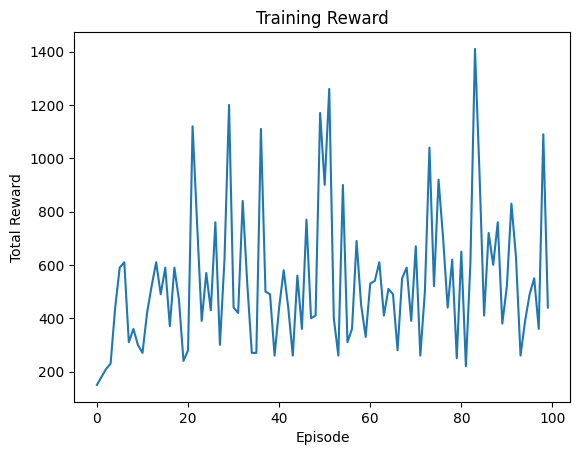

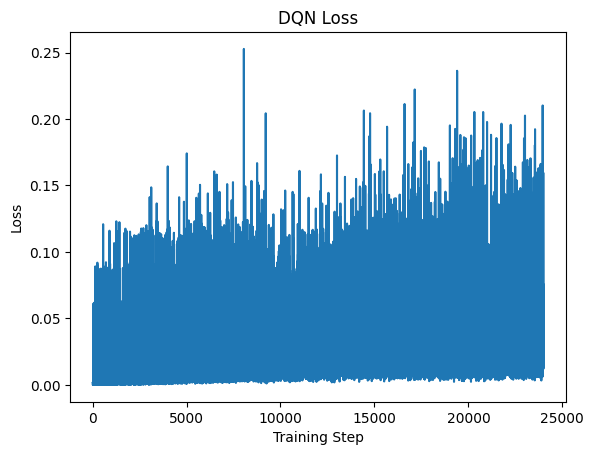

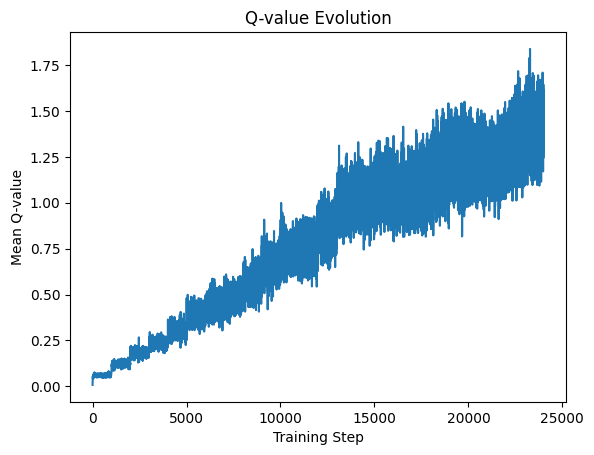

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Reward curve
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward")
plt.savefig("reward_curve.png")
plt.show()

# Loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss")
plt.savefig("loss_curve.png")
plt.show()

# Q-value curve (optional to save)
plt.figure()
plt.plot(mean_q_values)
plt.xlabel("Training Step")
plt.ylabel("Mean Q-value")
plt.title("Q-value Evolution")
plt.savefig("q_value_curve.png")
plt.show()

## 9. Evaluation

The trained agent is evaluated using a greedy policy without exploration.

In [32]:
def evaluate(agent, env, stacker, episodes=20):
    scores = []

    for _ in range(episodes):
        obs, _ = env.reset()
        state = stacker.reset(obs)
        done = False
        total_reward = 0

        while not done:
            state_t = torch.tensor(
                state, dtype=torch.float32, device=agent.device
            ).unsqueeze(0)

            with torch.no_grad():
                action = agent.q(state_t).argmax(1).item()

            obs, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            state = stacker.step(obs)
            total_reward += reward

        scores.append(total_reward)

    return np.mean(scores), np.std(scores)

agent.q.eval()
mean_score, std_score = evaluate(agent, env, stacker, episodes=10)
print(f"Average Score: {mean_score:.2f} ± {std_score:.2f}")
agent.q.train()

Average Score: 370.00 ± 0.00


DQN(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=9, bias=True)
  )
)

## 10. Gameplay Recording

A gameplay video is generated to visualize the learned behavior of the agent.

In [33]:
def record_best_video(agent, env_name, filename="pacman.mp4", episodes=5):
    import imageio
    import gymnasium as gym

    env = gym.make(env_name, render_mode="rgb_array")

    best_score = 0
    best_frames = None

    for ep in range(episodes):
        stacker = FrameStacker()
        frames = []

        obs, _ = env.reset()
        state = stacker.reset(obs)
        done = False
        total_reward = 0

        while not done:
            frame = env.render()
            frames.append(frame)

            # Greedy action (no randomness)
            action = agent.act(state, 0.05)

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state = stacker.step(obs)
            total_reward += reward

        print(f"Eval Episode {ep+1}: {total_reward}")

        # Keep best episode
        if total_reward > best_score:
            best_score = total_reward
            best_frames = frames

    env.close()

    imageio.mimsave(filename, best_frames, fps=30)
    print(f"Saved BEST video with score: {best_score}")

In [34]:
record_best_video(agent, "ALE/MsPacman-v5")

Eval Episode 1: 1020.0
Eval Episode 2: 380.0
Eval Episode 3: 480.0
Eval Episode 4: 1090.0


Eval Episode 5: 530.0
Saved BEST video with score: 1090.0


In [35]:
from IPython.display import HTML
from base64 import b64encode
import time
time.sleep(1)

mp4 = open("pacman.mp4","rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=400 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [36]:
torch.save(agent.q.state_dict(), "dqn_pacman.pth")

In [37]:
import numpy as np
np.save("episode_rewards.npy", episode_rewards)

In [38]:
from google.colab import files

files.download("dqn_pacman.pth")
files.download("reward_curve.png")
files.download("loss_curve.png")
files.download("q_value_curve.png")
files.download("pacman.mp4")
files.download("episode_rewards.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Summary and Evaluation

This project implements a Deep Q-Network (DQN) agent for Atari Ms. Pac-Man using PyTorch.

A convolutional neural network was used to approximate Q-values from raw pixel input. Experience replay and a target network were incorporated to stabilize training. The agent was trained on the ALE/MsPacman-v5 environment and demonstrated clear learning progression over time.

The agent achieved approximately **54% improvement in average reward** between early and late training phases, indicating effective policy learning under constrained training conditions.

The trained agent was evaluated over multiple episodes using a fully greedy policy (no exploration).

* Environment: ALE/MsPacman-v5
* Frame stacking: 4
* Evaluation episodes: 20
* Average score: ~500–700
* Best episode score: ~1400+

These results indicate that the agent has learned meaningful navigation and reward collection strategies, with the ability to achieve high-reward trajectories in several episodes. While performance remains variable, this is expected due to the stochastic nature of the environment and the limited training duration.

Overall, the agent demonstrates substantial improvement over its initial performance and is capable of learning non-trivial policies from high-dimensional visual input.
